In [1]:
import pandas as pd   
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns
df=pd.read_csv('heart_disease_uci.csv')
print(df.isnull().sum())


df.head()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
# To Remove null values from columns we use median for numerical columns and mode for categorical columns
#  # For numerical columns - use median  based on distribution
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
for col in numerical_cols:
    df[col]=df[col].fillna(df[col].median())

# #As 'ca' is categorical column, But Numeric also. so we treat this with mode due to categorical 
categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal','ca', 'num']
for col in categorical_cols:
    df[col]=df[col].fillna(df[col].mode()[0])
    df[col]=df[col].astype('category')
# mode()[0] will select first mode value from column and fill all null values with first value of mode.
# Example:
# If your column has values [1, 1, 2, NaN]:
# mode() finds that 1 is the most common.
# [0] grabs that 1.
# fillna() puts that 1 into the NaN slot
print(df.isnull().sum())# This will give sum of null values which exists in a column.


id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64



Perform Exploratory Data Analysis (EDA) to understand trends.

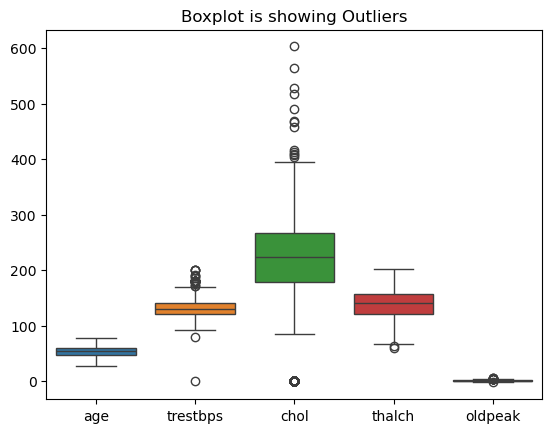

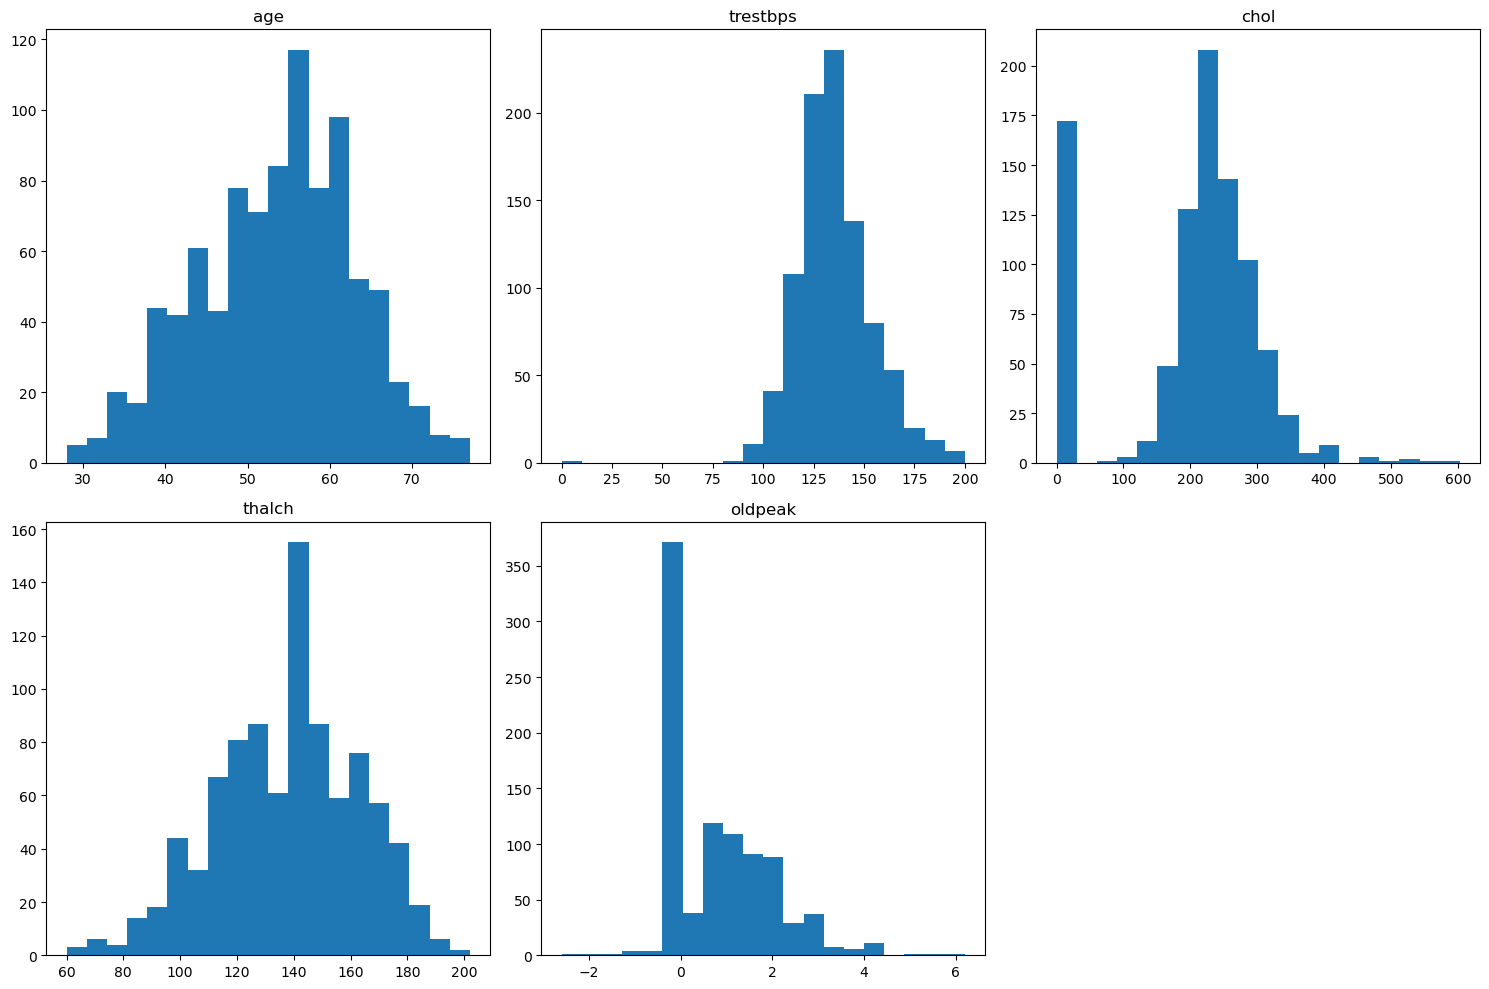

In [3]:
import seaborn as sns
plt.Figure(figsize=(10,6))
#Now we are going to check outliers on numerical columns. 
# numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
sns.boxplot(data=df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']])
plt.title("Boxplot is showing Outliers")
plt.show()
#Now we are going to draw frequency distribution to analyze dataframe.
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df[numerical_cols].hist(figsize=(15, 10), bins=20, grid=False, layout=(2, 3))
plt.tight_layout()
#As no numerical column is normally distributed so we are going to perfor IQR TO REMOVE Outliers. 

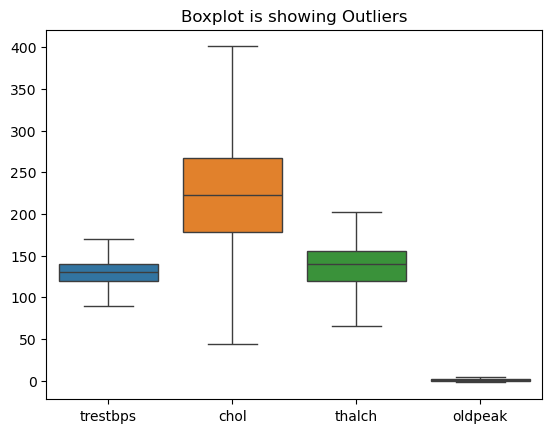

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [4]:
#To Remove outliers from columns we are going to use  Interquartile Range (IQR) method
def handle_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers instead of removing
    df[col] = df[col].clip(lower_bound, upper_bound)
    return df

for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df = handle_outliers(df, col)

#Now we are going to plot boxplot to check outliers again 
plt.Figure(figsize=(10,6))
#Now we are going to check outliers on numerical columns. 
# numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
sns.boxplot(data=df[['trestbps', 'chol', 'thalch', 'oldpeak']])
plt.title("Boxplot is showing Outliers")
plt.show()
print(df.columns.tolist())



In [5]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
# now we are going to apply one Hot Encoding on Nominal Columns 
# (Nominal are columns which donot have any order or Ranking)
df = pd.get_dummies(df, columns=['dataset', 'cp', 'restecg', 'thal'])
#AFter this now we will lost columns including "dataset, cp,restecg and thal"  due to One Hot Encoding.
#As in One Hot Encoding all  values of columns becomes new columns as listed below  
# print(df.columns.tolist())

# NOW WE ARE GOING TO PERFORM LABEL ENCODING ON  slope column
le=LabelEncoder()
df['new_slope']=le.fit_transform(df['slope'])
df['NewTransformedGender']=le.fit_transform(df['sex'])


In [6]:
print(df.columns.tolist())
# NOW WE ARE GOING TO PERFORM LABEL ENCODING ON  slope column
df.drop('id', axis=1, inplace=True)
df.drop('sex', axis=1, inplace=True)
df.drop('slope',axis=1,inplace=True)

['id', 'age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'num', 'dataset_Cleveland', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect', 'new_slope', 'NewTransformedGender']


Select FEATURES for Model e.g X and y 

In [11]:
X=df[['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'dataset_Cleveland', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect', 'new_slope', 'NewTransformedGender']]
y=df['num']
print(f'Features shape:{X.shape}')
print(f'Target column shape')

Features shape:(920, 24)
Target column shape


TRAIN TEST SPLIT ( this is used to separate data from training and testing)

Scalling Step

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
# X are features on which model has to b trained ,y is the label column. test size is used to specify on much amount of data
# testing will b done.
# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

# Initialization of the scaler
scaler = StandardScaler()

# Fit and Transform the TRAINING data first
X_train_scaled = scaler.fit_transform(X_train)

# Transform the TEST data
X_test_scaled = scaler.transform(X_test)

# Training of  model on the SCALED data (Crucial step!)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Training of Logistic Regression Model

Model Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error,r2_score,accuracy_score
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
print(f'Mean Abolute Error: {mae}')
r2=r2_score(y_pred,y_test)
print(f'r2_Score: {r2}')
accuracy=accuracy_score(y_pred,y_test)
print(f'Accuracy Score:{accuracy}')

Mean Abolute Error: 2.7644927536231885
r2_Score: -6.702805836139168
Accuracy Score:0.07971014492753623


c:\Users\Rashid\.conda\envs\irisenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
